# 使い方： `py4project`

In [1]:
import pandas as pd
import py4project as pyp

## データ

データ：経済センサス

- `w2016`：2016年従業者数
- `w2021`：2021年従業者数
- `e2016`：2016年事業所数
- `e2021`：2021年事業所数

In [2]:
df = pd.read_csv('data_project.csv')
df

,地域コード,地域,産業コード,産業,w2016,w2021,e2016,e2021
0,0,全国,AB,農林漁業,363024,453703,32676,42458
1,0,全国,C,鉱業，採石業，砂利採取業,19467,19697,1851,1865
2,0,全国,D,建設業,3690740,3737415,492734,485135
3,0,全国,E,製造業,8864253,8803643,454800,412617
4,0,全国,F,電気・ガス・熱供給・水道業,187818,202149,4654,9139
5,0,全国,G,情報通信業,1642042,1986839,63574,76559
6,0,全国,H,運輸業，郵便業,3197231,3264734,130459,128224
7,0,全国,I,卸売業，小売業,11843869,11611924,1355060,1228920
8,0,全国,J,金融業，保険業,1530002,1494436,84041,83852
9,0,全国,K,不動産業，物品賃貸業,1462395,1618138,353155,374456


## ボックスプロット

In [3]:
help(pyp.box_plot)

Help on function box_plot in module py4project.core:

box_plot(x, data, title='', text_col='産業', xlabel=None, xlog=False)
    箱ひげ図を表示する。

    データの散らばり方（中央値・四分位数・外れ値）を確認するための図です。
    箱の中の線が中央値、三角の印が平均値を表します。
    外れ値には自動的に名前が表示されるので、
    どの産業や都道府県が極端な値をとっているかが分かります。

    引数
    ----
    x : 文字列 または 文字列のリスト
        箱ひげ図にする変数の列名。
        リストで複数渡すと、横に並べて比較できます。
        例： x='地域固有効果'
        例： x=['全国成長効果', '産業構成効果', '地域固有効果']
    data : DataFrame
        xの列を含むデータフレーム。
    title : 文字列
        グラフの上に表示するタイトル。
    text_col : 文字列
        外れ値の横に表示する名前が入っている列名。初期値は '産業' です。
        名前は先頭6文字までが表示されます。
    xlabel : 文字列のリスト
        横軸に表示するラベルのリスト。
        省略するとxの列名がそのまま使われます。
        xに渡した列の数と同じ数のラベルを指定してください。
    xlog : True または False
        Trueでデータを常用対数（log10）に変換してから箱ひげ図を描きます。
        値の大きさが極端に違う場合に使います。

    使用例
    ------
    >>> box_plot('地域固有効果', df)
    >>> box_plot(['全国成長効果', '産業構成効果', '地域固有効果'], df)
    >>> box_plot('売上高', df, xlog=True)

    注意点
    ------
    xlog=True にする場合、対象の列に0以下の値

2016年の従業者数のボックスプロットを表示する。

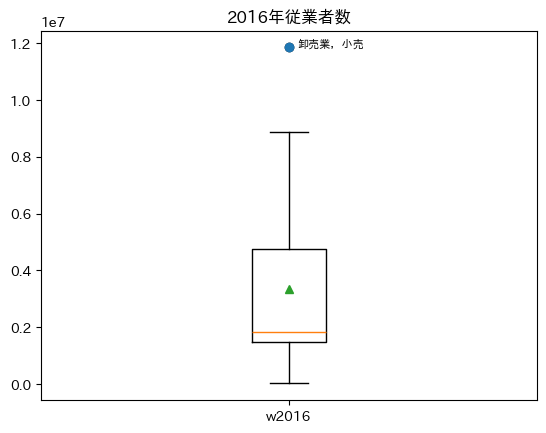

In [4]:
pyp.box_plot(x='w2016', data=df, title='2016年従業者数')

2016年と2021年の従業者数および事業所数のボックスプロットを表示する。

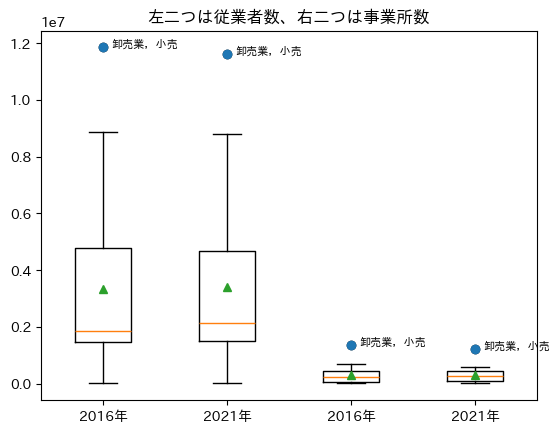

In [5]:
cols = ['w2016', 'w2021', 'e2016', 'e2021']
labels = ['2016年', '2021年', '2016年', '2021年']
pyp.box_plot(x=cols, data=df, xlabel=labels,
             title='左二つは従業者数、右二つは事業所数')

## 横バープロット

In [6]:
help(pyp.bar_plot)

Help on function bar_plot in module py4project.core:

bar_plot(x, data, title='', xlabel=None, unit=1000, sort_by='産業コード', tick_label='産業', ascending=None)
    横向きの棒グラフを表示する。

    産業ごとの値を横に並べた棒グラフを描きます。
    複数の列をリストで渡すと、それぞれを並べて比較できます。
    シフトシェア分析の3つの効果（全国成長効果・産業構成効果・地域固有効果）は
    授業資料と同じ色で自動的に塗り分けられます。

    引数
    ----
    x : 文字列 または 文字列のリスト
        棒の長さにする変数の列名。
        リストで複数渡すと、産業ごとに並べて表示されます。
        例： x='地域固有効果'
        例： x=['全国成長効果', '産業構成効果', '地域固有効果']
    data : DataFrame
        xの列を含むデータフレーム。
    title : 文字列
        グラフの上に表示するタイトル。
    xlabel : 文字列
        横軸のラベル。省略すると列名と単位から自動でつくられます。
    unit : 数値 または 辞書
        値を割る数。表示の桁を調整するために使います。
        1000 なら千単位、0.01 なら百分率（％）の表示になります。
        すべての列に同じ単位を使う場合は数値をひとつ渡します（初期値は1000）。
        列ごとに変えたい場合は辞書で渡します。
        例： unit={'地域固有効果': 1000, '特化係数': 1}
    sort_by : 文字列 または None
        棒を並べる順番を決める列名。初期値は '産業コード' です。
        値の大きい順に並べたいときは、その列名を指定します。
        Noneを渡すと、xの最初の列の値で並べ替えます。
    tick_label : 文字列
        縦軸に表示する名前が入っている列

2016年従業者数の産業別バープロットを表示する。

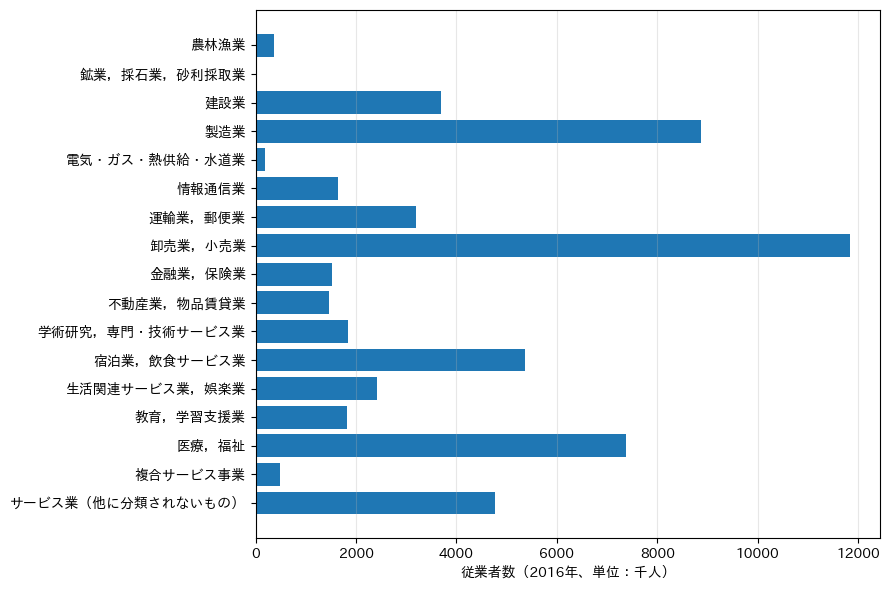

In [7]:
pyp.bar_plot('w2016', data=df, xlabel='従業者数（2016年、単位：千人）')

2016年と2021年の従業者数の産業別バープロットを表示する。

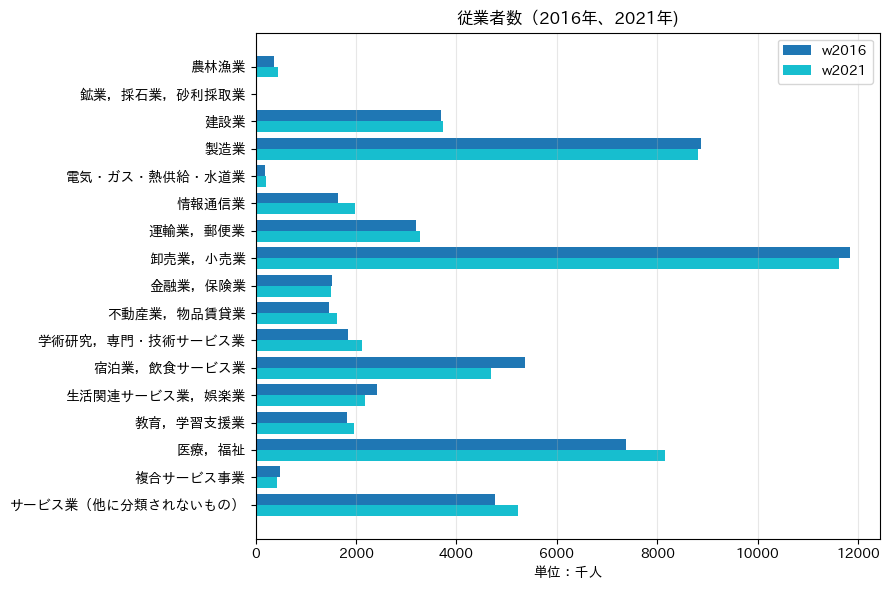

In [8]:
pyp.bar_plot(['w2016','w2021'], data=df, title='従業者数（2016年、2021年)', xlabel='単位：千人')

従業者数・事業所数の2016年から2021年にかけて変化率（パーセント表示）をバープロットとして表示する。

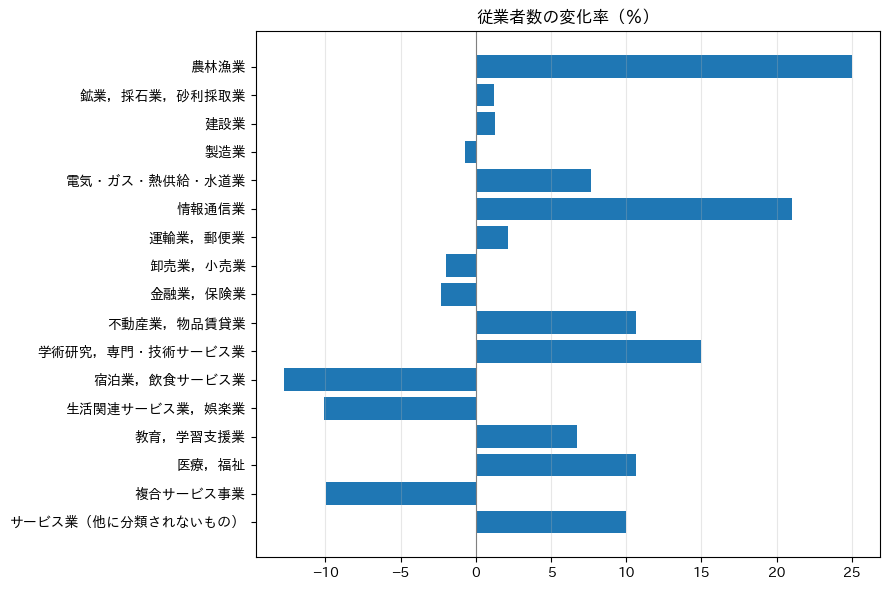

In [9]:
df['w変化率'] = df['w2021'] / df['w2016'] - 1
pyp.bar_plot('w変化率', data=df, title='従業者数の変化率（％）', xlabel='', unit=0.01)

## 散布図

In [10]:
help(pyp.scatter_plot)

Help on function scatter_plot in module py4project.core:

scatter_plot(x, y, data, title='', xlabel=None, ylabel=None, line=True, text=True, text_col='産業', xlog=False, ylog=False, xylog=False)
    散布図にトレンド線を重ねて表示する。

    regression_plotとよく似ていますが、こちらは回帰式や信頼区間を表示せず、
    データの傾向を目で確かめることを目的としています。
    値の大きさが極端に違う変数を扱うときは、対数化のオプションが使えます。

    引数
    ----
    x : 文字列
        横軸にする変数の列名。
    y : 文字列
        縦軸にする変数の列名。
    data : DataFrame
        xとyの列を含むデータフレーム。
    title : 文字列
        グラフの上に表示するタイトル。
    xlabel : 文字列
        横軸のラベル。省略するとxの列名がそのまま使われます。
    ylabel : 文字列
        縦軸のラベル。省略するとyの列名がそのまま使われます。
    line : True または False
        Trueでトレンド線（当てはめた直線）を引きます。
    text : True または False
        Trueで各点の横に名前を表示します。点が多くて重なる場合はFalseにしてください。
    text_col : 文字列
        点の横に表示する名前が入っている列名。初期値は '産業' です。
        名前は先頭6文字までが表示されます。
    xlog : True または False
        Trueで横軸の変数を常用対数（log10）に変換します。
    ylog : True または False
        Trueで縦軸の変数を常用対数（log10）に変換します。
    xylog : True または False
        True

2016年事業所数と従業者数の散布図を表示する。

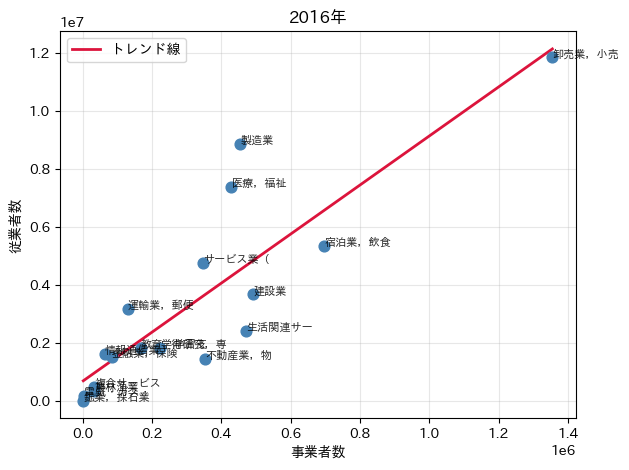

In [11]:
pyp.scatter_plot(x='e2016', y='w2016', data=df,
                 title='2016年', xlabel='事業者数', ylabel='従業者数')

常用対数に変換して2016年事業所数と従業者数の散布図を表示する。

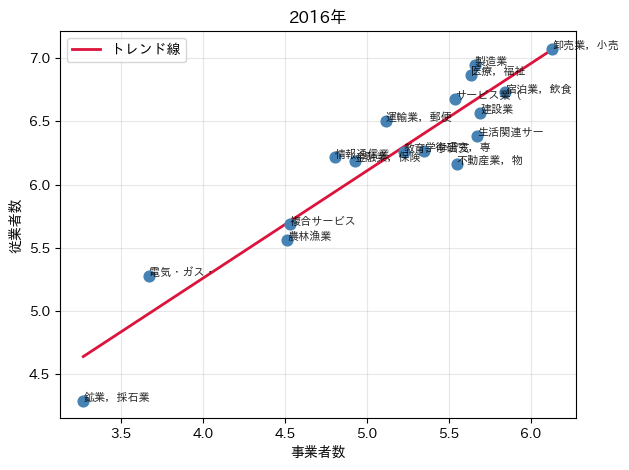

In [12]:
pyp.scatter_plot(x='e2016', y='w2016', data=df, xylog=True,
                 title='2016年', xlabel='事業者数', ylabel='従業者数')

横軸に2016年従業者数（常用対数）、縦軸に従業者数の変化率を使い、散布図を表示する。ただし、トレンド線は非表示とする。

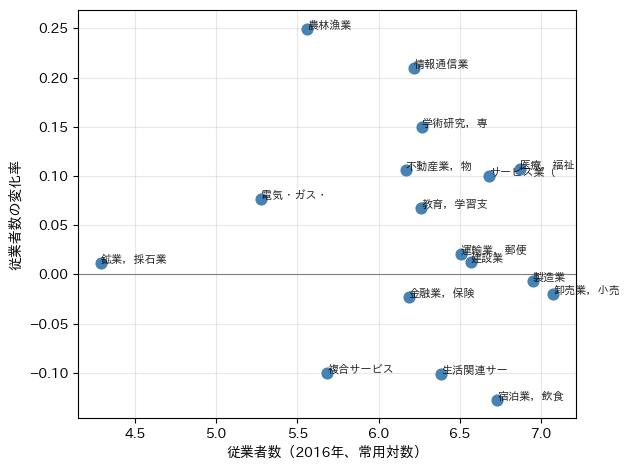

In [13]:
pyp.scatter_plot('w2016', 'w変化率', data=df, xlog=True, line=False,
                 xlabel='従業者数（2016年、常用対数）', ylabel='従業者数の変化率')

## 単回帰分析

In [14]:
help(pyp.regression)

Help on function regression in module py4project.core:

regression(x, y, data)
    回帰分析の結果を表示する。

    xを説明変数、yを被説明変数として単回帰分析をおこない、
    標本の大きさ・決定係数・傾きの95%信頼区間・回帰式を画面に表示します。

    ＊注意＊ 引数は「x（説明変数）→ y（被説明変数）→ data」の順です。
    回帰式 y = a × x + b の見た目とは順番が逆になるので気をつけてください。

    引数
    ----
    x : 文字列
        説明変数（横軸にあたる変数）の列名。
    y : 文字列
        被説明変数（縦軸にあたる変数）の列名。
    data : DataFrame
        xとyの列を含むデータフレーム。

    表示される内容
    --------------
    標本の大きさ n : 分析に使ったデータの行数。
    決定係数 R²    : xがyの変動をどれくらい説明できているかを示す0〜1の値。
                     1に近いほどよく説明できている。
    信頼区間 (95%) : 傾きの値がこの範囲に入ると考えられる区間。
                     この区間が1をまたいでいなければ、傾きは1と異なると判断できる。
    回帰式         : 推定された直線の式。

    使用例
    ------
    >>> regression('全国成長効果', '実際の変化', df)



次の推定式を使い回帰分析をおこなう。

$$
\text{従業者数}_i = b_0 + b_1 \times\text{事業所数}_i+u_i
$$

In [15]:
df['従業者数'] = df['w2016']
df['事業所数'] = df['e2016']
pyp.regression(x='事業所数', y='従業者数', data=df)

推定式:  yᵢ = b₀ + b₁·xᵢ + uᵢ,  i = 1, 2, …, n
標本の大きさ(n): 17
決定係数(R²) : 0.740
b₀ の推定値  : 693261.811
b₁ の推定値  : 8.442
b₁ の95%信頼区間 : [5.687, 11.197]


## 単回帰分析：散布図

In [16]:
help(pyp.regression_plot)

Help on function regression_plot in module py4project.core:

regression_plot(x, y, data, title='', xlabel=None, ylabel=None, line=True, text=True, text_col='産業')
    散布図に回帰直線を重ねて表示する。

    点の散らばり方と、そこに当てはめた直線を同時に確認できます。
    タイトル部分には回帰式と傾きの95%信頼区間も表示されます。

    ＊注意＊ 引数は「x（説明変数）→ y（被説明変数）→ data」の順です。

    引数
    ----
    x : 文字列
        横軸にする変数（説明変数）の列名。
    y : 文字列
        縦軸にする変数（被説明変数）の列名。
    data : DataFrame
        xとyの列を含むデータフレーム。
    title : 文字列
        グラフの上に表示するタイトル。省略すると回帰式だけが表示されます。
    xlabel : 文字列
        横軸のラベル。省略するとxの列名がそのまま使われます。
    ylabel : 文字列
        縦軸のラベル。省略するとyの列名がそのまま使われます。
    line : True または False
        Trueで回帰直線を引きます。Falseにすると点だけの散布図になります。
    text : True または False
        Trueで各点の横に名前を表示します。点が多くて重なる場合はFalseにしてください。
    text_col : 文字列
        点の横に表示する名前が入っている列名。初期値は '産業' です。
        都道府県名を表示したい場合は text_col='都道府県' のように指定します。
        名前は先頭6文字までが表示されます。

    使用例
    ------
    >>> regression_plot('特化係数', '地域固有効果', df, title='大阪府')
    >>> regression_plot('特化係数',

上の回帰分析の回帰直線とデータの散布図を表示する。

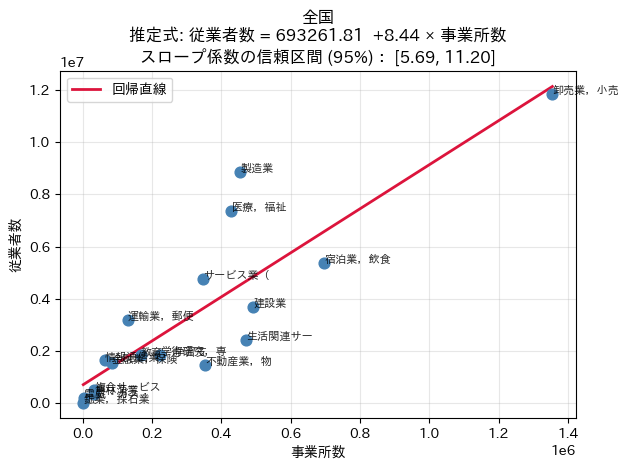

In [17]:
pyp.regression_plot(x='事業所数', y='従業者数', title='全国', data=df)